In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


Linear advection

In [2]:
z = np.linspace(0, 140, 200)
t =np.linspace(0, 1.6, 200)  # in years

# Parameters (you can change these)
alpha = 1.74
Da=1
kappa = 1.42*10**(-2)
lambda_ = np.sqrt(alpha/Da)

def z_of_s(s, z, t):
    return 150 + (z - 150) * np.exp(244 * (t - s))

def integrand(s, z, t):
    z_s = z_of_s(s, z, t)
    return alpha * np.exp(-lambda_ * z_s) * np.exp(-(kappa - 244) * (t - s))

def t0(z, t):
    # characteristic hits boundary z=0
    tau = (1 / 244) * np.log(150 / (150 - z))
    return max(0.0, t - tau)

def B(z, t):
    lower = t0(z, t)
    result, _ = quad(integrand, lower, t, args=(z, t))
    return result

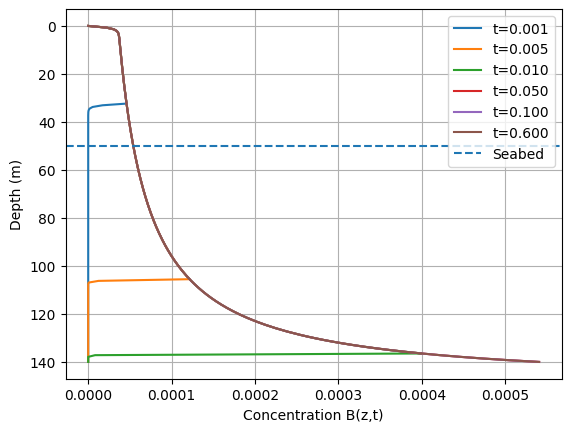

In [3]:
z_vals = np.linspace(0, 140, 200)
t_values = [0.001, 0.005, 0.01, 0.05, 0.1,0.6]

A = np.exp(-lambda_ * z_vals)


plt.figure()

for t in t_values:
    B_vals = [B(z, t) for z in z_vals]
    plt.plot(B_vals, z_vals, label=f"t={t:.3f}")
plt.axhline(y=50, linestyle='--',label="Seabed")
plt.gca().invert_yaxis()
#plt.plot(A, z_vals, label="A(z)", linestyle='--', color='black')
plt.xlabel("Concentration B(z,t)")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid()

plt.show()

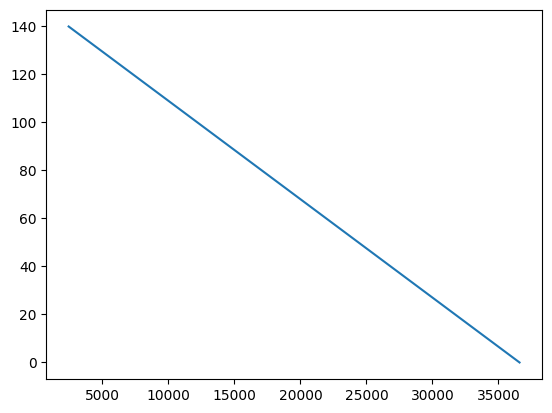

In [4]:
u= 3.66*10**4-244*z
plt.plot(u,z, label="u(z)")

damkohler number

In [5]:
print(kappa/244)

5.81967213114754e-05


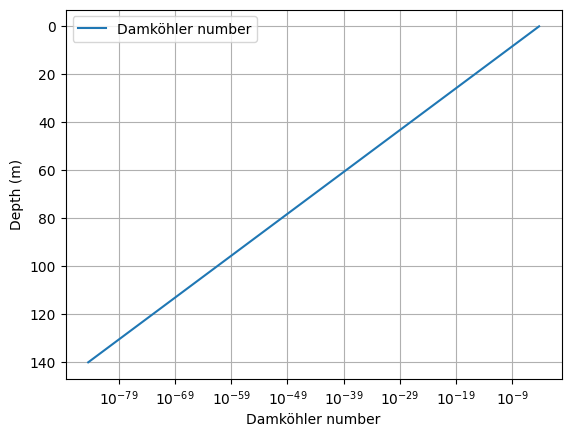

In [6]:
Transport_timescale = 1 / 244
reaction_timescale = 1 / kappa
Damkohler = kappa/244*A
plt.figure()
plt.semilogx(Damkohler, z, label="Damköhler number")
plt.gca().invert_yaxis()
plt.xlabel("Damköhler number")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid()
plt.show()